# Credit Card Fraud Detection with XGBoost and Optuna

In [1]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import precision_recall_curve, auc
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Load and Prepare Data

In [ ]:
# Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud 

# zscore function
def z_score(df): return (df - df.mean()) / df.std(ddof=0)

# Load the data
df = pd.read_csv('./creditcard.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [3]:
# Split the dataset into training and test datasets
train, test = train_test_split(df, test_size=0.3, shuffle=False)

cols = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10','V11','V12','V13','V14',
        'V15','V16','V17','V18','V19','V20','V21','V22','V23','V24','V25','V26',
        'V27','V28']

xtrain = train[cols]
ytrain = train['Class']
xtest = test[cols]
ytest = test['Class']

## Train XGBoost Model

In this credit card fraud detection task, the Precision-Recall AUC (PR AUC) is used as the evaluation metric instead of the more common ROC AUC. The primary reason is the severe class imbalance in the dataset, where fraudulent transactions account for only approximately 0.17% of all records. Under such conditions, ROC AUC can be misleading — a naive model that predicts every transaction as legitimate would still achieve a ROC AUC close to 1.0, since the True Positive Rate and False Positive Rate are both dominated by the overwhelming majority class. PR AUC, on the other hand, focuses exclusively on the minority class (fraud), measuring the trade-off between Precision (how many flagged transactions are actually fraud) and Recall (how many actual frauds are caught). This makes PR AUC a far more informative and honest metric when the cost of missing a fraudulent transaction is high and the positive class is rare.

In [5]:
XGB = XGBClassifier(
    n_estimators=30, #number of trees
    n_jobs=-1,
    use_label_encoder=False, #off auto labe by xgboost
    eval_metric='aucpr'
)

XGB.fit(
    xtrain,
    ytrain,
    eval_set=[(xtrain, ytrain), (xtest, ytest)]
)

[0]	validation_0-aucpr:0.80695	validation_1-aucpr:0.74619
[1]	validation_0-aucpr:0.84154	validation_1-aucpr:0.74527
[2]	validation_0-aucpr:0.85015	validation_1-aucpr:0.76565
[3]	validation_0-aucpr:0.85374	validation_1-aucpr:0.76592
[4]	validation_0-aucpr:0.88203	validation_1-aucpr:0.78627
[5]	validation_0-aucpr:0.88874	validation_1-aucpr:0.78209
[6]	validation_0-aucpr:0.89629	validation_1-aucpr:0.79267
[7]	validation_0-aucpr:0.90079	validation_1-aucpr:0.79191
[8]	validation_0-aucpr:0.90282	validation_1-aucpr:0.79785
[9]	validation_0-aucpr:0.90759	validation_1-aucpr:0.80005
[10]	validation_0-aucpr:0.91283	validation_1-aucpr:0.79673
[11]	validation_0-aucpr:0.91707	validation_1-aucpr:0.79725
[12]	validation_0-aucpr:0.92503	validation_1-aucpr:0.79488
[13]	validation_0-aucpr:0.93069	validation_1-aucpr:0.79413
[14]	validation_0-aucpr:0.93512	validation_1-aucpr:0.79339
[15]	validation_0-aucpr:0.94085	validation_1-aucpr:0.79188
[16]	validation_0-aucpr:0.94494	validation_1-aucpr:0.79243
[17]	va

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=30, n_jobs=-1,
              num_parallel_tree=None, random_state=None, ...)

## Feature Importance and Evaluation

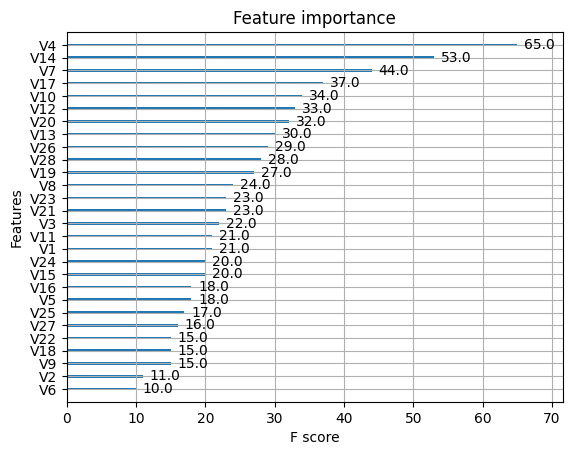

Training PR AUC: 0.990
Test PR AUC: 0.790


In [6]:
# Plot feature importance
plot_importance(XGB)
plt.show()

predclasstrain = XGB.predict_proba(xtrain)[:, 1]
predclasstest = XGB.predict_proba(xtest)[:, 1]

# Training
precision_train, recall_train, _ = precision_recall_curve(ytrain, predclasstrain)
aucpr_train = auc(recall_train, precision_train)

# Test
precision_test, recall_test, _ = precision_recall_curve(ytest, predclasstest)
aucpr_test = auc(recall_test, precision_test)

print('Training PR AUC: ' + "{:.3f}".format(aucpr_train))
print('Test PR AUC: ' + "{:.3f}".format(aucpr_test))

## Hyperparameter Tuning with Optuna

In [7]:
!pip install optuna


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [8]:
import optuna
import warnings
warnings.filterwarnings('ignore')

def objective(trial):
    """Define the objective function"""
    params = {
        'max_depth': trial.suggest_int('max_depth', 1, 6), #change max depth = 6
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 200), #change to max 200 trees
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.01, 1.0, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.01, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'eval_metric': 'aucpr',
        'use_label_encoder': False
    }

    # Fit the model
    optuna_model = XGBClassifier(**params)
    optuna_model.fit(xtrain, ytrain)

    # Predict probabilities
    y_pred = optuna_model.predict_proba(xtest)[:, 1]

    # Compute AUCPR
    precision, recall, _ = precision_recall_curve(ytest, y_pred)
    aucpr = auc(recall, precision)

    return aucpr

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

[I 2026-04-02 10:11:59,291] A new study created in memory with name: no-name-3cf06149-149e-45cc-9c0c-3c4f567866bd
[I 2026-04-02 10:11:59,705] Trial 0 finished with value: 0.7431705869310095 and parameters: {'max_depth': 4, 'learning_rate': 0.015271099469351691, 'n_estimators': 74, 'min_child_weight': 8, 'gamma': 0.05880490733143559, 'subsample': 0.01782945537891847, 'colsample_bytree': 0.05797372722077006, 'reg_alpha': 0.10561039352710598, 'reg_lambda': 0.0034112069151618287}. Best is trial 0 with value: 0.7431705869310095.
[I 2026-04-02 10:12:00,473] Trial 1 finished with value: 0.7698628603887411 and parameters: {'max_depth': 1, 'learning_rate': 0.09833294481239935, 'n_estimators': 192, 'min_child_weight': 10, 'gamma': 2.582588126409133e-06, 'subsample': 0.043961067896836487, 'colsample_bytree': 0.18606874049048008, 'reg_alpha': 6.347987233961307e-05, 'reg_lambda': 0.0004056272965685603}. Best is trial 1 with value: 0.7698628603887411.
[I 2026-04-02 10:12:01,160] Trial 2 finished wit

## Best Trial Results

In [9]:
print('Number of finished trials: {}'.format(len(study.trials)))
print('Best trial:')
trial = study.best_trial

print('  Value: {}'.format(trial.value))
print('  Params: ')
for key, value in trial.params.items():
    print('    {}: {}'.format(key, value))

Number of finished trials: 30
Best trial:
  Value: 0.8106242175198912
  Params: 
    max_depth: 5
    learning_rate: 0.020858006199922233
    n_estimators: 117
    min_child_weight: 3
    gamma: 0.0107748638170898
    subsample: 0.764922013296604
    colsample_bytree: 0.9324386822235096
    reg_alpha: 0.009799929605239526
    reg_lambda: 1.5790949816091554e-08


The Optuna hyperparameter tuning improved the model's PR AUC from 0.79 (baseline) to 0.8106, representing a +2.6% improvement over 30 trials.

The best configuration selected by Optuna reveals several notable patterns. A relatively shallow tree depth of 5 combined with a low learning rate of 0.021 suggests that the model benefits from learning slowly and conservatively, reducing the risk of overfitting. Only 117 estimators were needed — well below the maximum of 500, indicating that additional trees beyond this point offer diminishing returns. A subsample rate of 0.765 introduces sufficient randomness across trees to improve generalization, while a colsample ratio of 0.93 retains nearly all features, reflecting the importance of the PCA components in distinguishing fraudulent transactions.

On the regularization side, both reg_alpha and reg_lambda are near zero, suggesting that the model relies more on tree structure constraints (depth, min_child_weight, gamma) rather than weight penalization to control complexity.

Overall, the tuned model strikes a good balance between bias and variance, and the improvement in PR AUC is meaningful in the context of fraud detection, where even a marginal gain in precision or recall can translate to catching more fraudulent transactions without increasing false alarms.

## Train Final Model with Best Parameters

In [10]:
params = trial.params
params['eval_metric'] = 'aucpr'
params['use_label_encoder'] = False

model = XGBClassifier(**params)
model.fit(xtrain, ytrain)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9324386822235096, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='aucpr', feature_types=None, gamma=0.0107748638170898,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.020858006199922233,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=117, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

## Optuna Visualizations

In [11]:
optuna.visualization.plot_optimization_history(study)

In [12]:
optuna.visualization.plot_param_importances(study)

In [13]:
optuna.visualization.plot_slice(study)